In [42]:
from sklearn import datasets

In [43]:
dir(datasets)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_arff_parser',
 '_base',
 '_california_housing',
 '_covtype',
 '_kddcup99',
 '_lfw',
 '_olivetti_faces',
 '_openml',
 '_rcv1',
 '_samples_generator',
 '_species_distributions',
 '_svmlight_format_fast',
 '_svmlight_format_io',
 '_twenty_newsgroups',
 'clear_data_home',
 'data',
 'descr',
 'dump_svmlight_file',
 'fetch_20newsgroups',
 'fetch_20newsgroups_vectorized',
 'fetch_california_housing',
 'fetch_covtype',
 'fetch_file',
 'fetch_kddcup99',
 'fetch_lfw_pairs',
 'fetch_lfw_people',
 'fetch_olivetti_faces',
 'fetch_openml',
 'fetch_rcv1',
 'fetch_species_distributions',
 'get_data_home',
 'load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine',
 'make_biclusters',
 'make_blobs',


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
iris=datasets.load_iris()

In [46]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [47]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [48]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [49]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [50]:
# df.describe(include='o') # to check for categorical data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


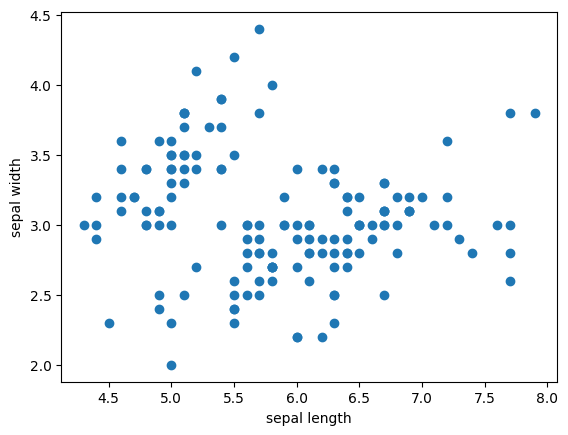

In [51]:
plt.scatter(df['sepal length (cm)'],df['sepal width (cm)'])
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

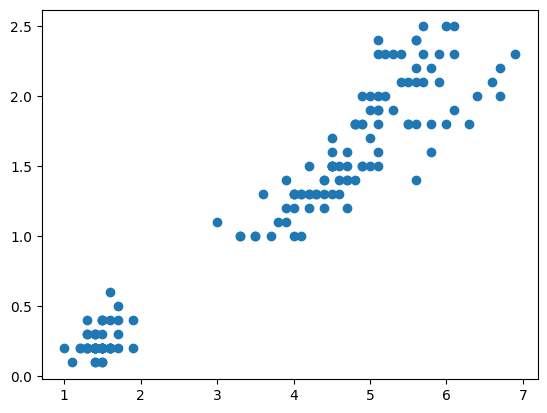

In [52]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])


In [53]:
# y= mx+c for linear regression
# y= m1x1+m2x2+m3x3+c multi linear regression


In [54]:
x=df.drop('target',axis=1)

In [55]:
y=df.target

In [56]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [57]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [59]:
len(x_train)

120

In [60]:
len(x_test)

30

In [61]:
len(y_train)

120

In [62]:
len(y_test)

30

In [63]:
from sklearn. linear_model import LogisticRegression

In [64]:
le=LogisticRegression()

In [65]:
le.fit(x_train,y_train)

LogisticRegression()

In [66]:
le.score(x_train,y_train)

0.975

In [67]:
y_predict=le.predict(x_test)

In [68]:
y_predict

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [69]:
le.score(x_test,y_test)

1.0

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predict)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


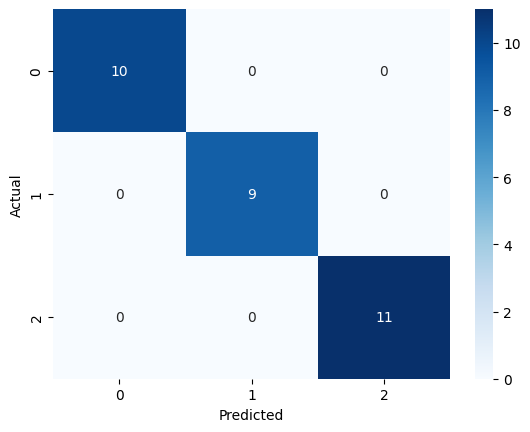

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)   # fit ONLY on training
X_test_scaled = scaler.transform(x_test)         # transform test

In [75]:
le.fit(X_train_scaled, y_train)

LogisticRegression()

In [76]:
y_preded = le.predict(X_test_scaled)

In [77]:
scaler.fit(x_train)
scaler.transform(x_train)
scaler.transform(x_test)

array([[ 0.35451684, -0.58505976,  0.55777524,  0.02224751],
       [-0.13307079,  1.65083742, -1.16139502, -1.17911778],
       [ 2.30486738, -1.0322392 ,  1.8185001 ,  1.49058286],
       [ 0.23261993, -0.36147005,  0.44316389,  0.4227026 ],
       [ 1.2077952 , -0.58505976,  0.61508092,  0.28921757],
       [-0.49876152,  0.75647855, -1.27600637, -1.04563275],
       [-0.2549677 , -0.36147005, -0.07258719,  0.15573254],
       [ 1.32969211,  0.08570939,  0.78699794,  1.49058286],
       [ 0.47641375, -1.92659808,  0.44316389,  0.4227026 ],
       [-0.01117388, -0.80864948,  0.09932984,  0.02224751],
       [ 0.84210448,  0.30929911,  0.78699794,  1.09012776],
       [-1.23014297, -0.13788033, -1.33331205, -1.44608785],
       [-0.37686461,  0.98006827, -1.39061772, -1.31260282],
       [-1.10824606,  0.08570939, -1.27600637, -1.44608785],
       [-0.86445224,  1.65083742, -1.27600637, -1.17911778],
       [ 0.59831066,  0.53288883,  0.55777524,  0.55618763],
       [ 0.84210448, -0.

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [79]:
import warnings
warnings.filterwarnings('ignore')

In [80]:
print("Before scaling:", le.score(x_test, y_test))
print("After scaling:", le.score(X_test_scaled, y_test))

Before scaling: 0.36666666666666664
After scaling: 1.0


In [81]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_preded))

Accuracy: 1.0


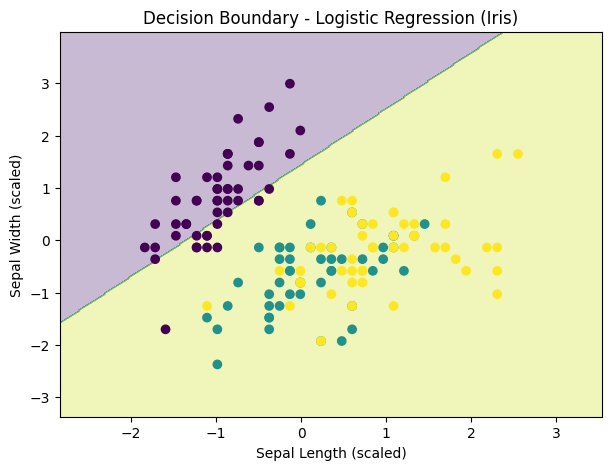

In [85]:
X_scaled = scaler.transform(x)

# Model
model = LogisticRegression()
model.fit(X_scaled, y)

# Create mesh grid using the first two features (Sepal Length and Sepal Width)
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prepare the input for prediction: combine meshgrid with mean of other features
# The model was trained on 4 features, so the prediction input must also have 4 features.
n_features = X_scaled.shape[1] # Get the number of features the model was trained on (should be 4)
X_meshgrid_input = np.zeros((xx.size, n_features))
X_meshgrid_input[:, 0] = xx.ravel()
X_meshgrid_input[:, 1] = yy.ravel()
# Set the remaining features (petal length and petal width) to their mean values from X_scaled
X_meshgrid_input[:, 2] = X_scaled[:, 2].mean()
X_meshgrid_input[:, 3] = X_scaled[:, 3].mean()

# Predict grid
Z = model.predict(X_meshgrid_input)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual points (using only the first two features for visualization)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("Decision Boundary - Logistic Regression (Iris)")
plt.show()